## ۱) بررسی GPU

In [2]:
import torch
assert torch.cuda.is_available(), "Select Runtime > Change runtime type > T4 GPU first."
print(torch.cuda.get_device_name(0))


Tesla T4


## ۲) نصب کتابخانه‌ها

In [3]:
import subprocess, sys, os, glob, shutil, site

os.environ["USE_TF"] = "0"


subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q",
                 "diffusers", "transformers", "accelerate"])
for pkg in ("diffusers", "transformers", "accelerate"):
    for base in site.getsitepackages() + [site.getusersitepackages()]:
        for path_ in glob.glob(os.path.join(base, pkg)):
            shutil.rmtree(path_, ignore_errors=True)

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir",
    "diffusers==0.37.0", "transformers==4.57.6", "accelerate==1.12.0"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "flask", "flask-cors", "pyngrok", "ultralytics", "segment-anything",
    "opencv-python-headless", "safetensors"])

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "simple-lama-inpainting"])


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 258.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 282.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 328.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 365.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 377.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 6.5 MB/s eta 0:00:00


0

## ۳) آماده‌سازی مسیرهای ذخیره‌سازی

In [4]:
import os, torch

CACHE_DIR = "/content/interior_v2/models" if os.path.isdir("/content") else "/kaggle/working/models"
OUTPUT_DIR = "/content/interior_v2/outputs" if os.path.isdir("/content") else "/kaggle/working/outputs"
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("CACHE_DIR:", CACHE_DIR)


CACHE_DIR: /content/interior_v2/models


## ۴) بارگذاری مدل‌ها — دو مدل، لود تنبل



In [5]:
import gc
from diffusers import (
    ControlNetModel, AutoencoderKL, UniPCMultistepScheduler,
    StableDiffusionControlNetImg2ImgPipeline, StableDiffusionInpaintPipeline,
    StableDiffusionXLControlNetImg2ImgPipeline, AutoPipelineForInpainting,
)

style_pipe = None
inpaint_pipe = None
_current_model = {"name": None, "need": None}

GEN_PARAMS = {
    "fast":    {"guidance_scale": 9.0, "controlnet_conditioning_scale": 1.05},
    "quality": {"guidance_scale": 7.0, "controlnet_conditioning_scale": 0.5},
}


SD15_CHECKPOINT = "SG161222/Realistic_Vision_V6.0_B1_noVAE"
SD15_VAE = "stabilityai/sd-vae-ft-mse"
SDXL_CHECKPOINT = "RunDiffusion/Juggernaut-XL-v9"


def _load_sd15_style():
    global style_pipe
    print(f"Loading {SD15_CHECKPOINT} (Fast mode, style)...")
    cn = ControlNetModel.from_pretrained(
        "lllyasviel/control_v11p_sd15_canny", torch_dtype=torch.float16, cache_dir=CACHE_DIR
    )
    vae15 = AutoencoderKL.from_pretrained(SD15_VAE, torch_dtype=torch.float16, cache_dir=CACHE_DIR)
   
    style_pipe = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
        SD15_CHECKPOINT, controlnet=cn, vae=vae15, torch_dtype=torch.float16,
        safety_checker=None, cache_dir=CACHE_DIR
    )
    style_pipe.scheduler = UniPCMultistepScheduler.from_config(style_pipe.scheduler.config)
    style_pipe.load_ip_adapter("h94/IP-Adapter", subfolder="models", weight_name="ip-adapter-plus_sd15.bin")  # Plus: patch embeddings, حفظ جزئیات مرجع بهتر از نسخهٔ پایه
    style_pipe.set_ip_adapter_scale(0.0)
    style_pipe.enable_model_cpu_offload()
    style_pipe.enable_vae_tiling()
    print(f" {SD15_CHECKPOINT} ready (fast, photorealism-tuned, Img2Img)")


def _load_sd15_inpaint():
    global inpaint_pipe
    print("Loading SD1.5 inpainting (Fast mode)...")
    inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
        "stable-diffusion-v1-5/stable-diffusion-inpainting",
        torch_dtype=torch.float16, safety_checker=None, cache_dir=CACHE_DIR
    )
    inpaint_pipe.enable_model_cpu_offload()
    print(" SD1.5 inpainting ready")


def _load_sdxl_style():
    global style_pipe
    print(f"Loading {SDXL_CHECKPOINT} (Quality mode, style)... (bigger — first time downloads more)")
    cn = ControlNetModel.from_pretrained(
        "diffusers/controlnet-canny-sdxl-1.0", torch_dtype=torch.float16, cache_dir=CACHE_DIR,
        variant="fp16", use_safetensors=True,
    )
    vae = AutoencoderKL.from_pretrained(
        "madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16, cache_dir=CACHE_DIR
    )
    
    from transformers import CLIPVisionModelWithProjection
    image_encoder = CLIPVisionModelWithProjection.from_pretrained(
        "h94/IP-Adapter", subfolder="models/image_encoder", torch_dtype=torch.float16, cache_dir=CACHE_DIR,
    )
    style_pipe = StableDiffusionXLControlNetImg2ImgPipeline.from_pretrained(
        SDXL_CHECKPOINT, controlnet=cn, vae=vae, image_encoder=image_encoder, torch_dtype=torch.float16, cache_dir=CACHE_DIR,
        variant="fp16", use_safetensors=True,
    )
    style_pipe.scheduler = UniPCMultistepScheduler.from_config(style_pipe.scheduler.config)
    
    style_pipe.load_ip_adapter("h94/IP-Adapter", subfolder="sdxl_models", weight_name="ip-adapter-plus_sdxl_vit-h.safetensors")  # Plus: حفظ جزئیات مرجع بهتر از نسخهٔ پایه
    style_pipe.set_ip_adapter_scale(0.0)
    style_pipe.enable_model_cpu_offload()
    style_pipe.enable_vae_tiling()
    print(f" {SDXL_CHECKPOINT} ready (slower, best photorealism, Img2Img)")


def _load_sdxl_inpaint():
    global inpaint_pipe
    print("Loading SDXL inpainting (Quality mode)...")
   
    inpaint_pipe = AutoPipelineForInpainting.from_pretrained(
        "diffusers/stable-diffusion-xl-1.0-inpainting-0.1",
        torch_dtype=torch.float16, cache_dir=CACHE_DIR,
        variant="fp16", use_safetensors=True,
    )
    inpaint_pipe.enable_model_cpu_offload()
    print(" SDXL inpainting ready")


def _unload_all():
    global style_pipe, inpaint_pipe
    if style_pipe is not None:
        style_pipe.to("cpu")
        del style_pipe
        style_pipe = None
    if inpaint_pipe is not None:
        inpaint_pipe.to("cpu")
        del inpaint_pipe
        inpaint_pipe = None
    gc.collect()
    torch.cuda.empty_cache()



def ensure_model(name, need="style"):
    """name: "fast" (Realistic Vision / SD1.5) or "quality" (Juggernaut XL / SDXL).
    need: "style" (generate_style, add_object_from_reference) or "inpaint" (edit_object,
    delete/furnish/texture operations). Only ever ONE pipeline is resident at a time."""
    global style_pipe, inpaint_pipe
    name = name if name in ("fast", "quality") else "fast"
    need = need if need in ("style", "inpaint") else "style"
    if _current_model["name"] == name and _current_model["need"] == need:
        return
    if _current_model["name"] is not None:
        print(f"Switching model: {_current_model['name']}/{_current_model['need']} -> {name}/{need} (unloading previous one)...")
    _unload_all()
    if need == "style":
        (_load_sdxl_style if name == "quality" else _load_sd15_style)()
    else:
        (_load_sdxl_inpaint if name == "quality" else _load_sd15_inpaint)()
    _current_model["name"] = name
    _current_model["need"] = need


print(" Model loader ready — ensure_model('fast'/'quality', need='style'/'inpaint')")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


 Model loader ready — ensure_model('fast'/'quality', need='style'/'inpaint')


In [6]:
ensure_model("fast", need="style")


Loading SG161222/Realistic_Vision_V6.0_B1_noVAE (Fast mode, style)...


config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

models/image_encoder/model.safetensors:   0%|          | 0.00/2.53G [00:00<?, ?B/s]

 SG161222/Realistic_Vision_V6.0_B1_noVAE ready (fast, photorealism-tuned, Img2Img)


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2290: FutureWarning: `enable_vae_tiling` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_tiling()` on a `StableDiffusionControlNetImg2ImgPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_tiling()`.
  deprecate(


## ۵) تشخیص اشیا — YOLOv8 + SAM

In [7]:
from ultralytics import YOLO

yolo_model = YOLO("yolov8x.pt")
yolo_model.to("cpu")
print(" YOLOv8 loaded (CPU)!")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
 YOLOv8 loaded (CPU)!


In [8]:
from segment_anything import sam_model_registry, SamPredictor
import requests

sam_path = os.path.join(CACHE_DIR, "sam_vit_h.pth")

if not os.path.exists(sam_path):
    print("Downloading SAM model... (2-3 minutes)")
    url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()
    with open(sam_path + ".part", "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    os.replace(sam_path + ".part", sam_path)
    response.close()
    print("SAM downloaded!")
else:
    print(" SAM already exists")

sam = sam_model_registry["vit_h"](checkpoint=sam_path)
sam.to("cpu")  
sam_predictor = SamPredictor(sam)
print(" SAM loaded (CPU)!")


SAM downloaded!
✅ SAM loaded (CPU)!


## ۶)  تبدیل تصویر، انتخاب ناحیه

In [9]:
import base64, io, hashlib, threading, uuid as _uuid
from collections import OrderedDict
import numpy as np, cv2
from PIL import Image, ImageOps

MODEL_LOCK = threading.RLock()
IMAGE_STORE, REGION_STORE = OrderedDict(), OrderedDict()
MAX_IMAGES, MAX_REGION_SETS = 16, 8


def _decode_image(value):
    if not isinstance(value, str) or not value:
        raise ValueError("image must be base64")
    try:
        raw = base64.b64decode(value.split(",", 1)[-1], validate=True)
    except Exception as exc:
        raise ValueError("Invalid base64 image data") from exc
    try:
        im = Image.open(io.BytesIO(raw))
        im.load()  
    except Exception as exc:
        raise ValueError("Could not read this file as an image; use JPEG, PNG or WEBP (not HEIC/HEIF)") from exc
    if im.width * im.height > 16_000_000:
        raise ValueError(
            f"Image is {im.width}x{im.height} ({im.width * im.height / 1_000_000:.1f} megapixels); "
            "max is 16 megapixels — a modern phone photo can exceed this, resize it first"
        )
    return ImageOps.exif_transpose(im)


def base64_to_pil(value):
    return _decode_image(value).convert("RGB")


def base64_to_pil_rgba(value):
    return _decode_image(value).convert("RGBA")


def pil_to_base64(im):
    b = io.BytesIO()
    im.save(b, format="PNG")
    return base64.b64encode(b.getvalue()).decode()


def image_key(im):
    return hashlib.sha256(str(im.size).encode() + im.tobytes()).hexdigest()


def remember_image(im):
    key = _uuid.uuid4().hex
    IMAGE_STORE[key] = pil_to_base64(im)
    while len(IMAGE_STORE) > MAX_IMAGES:
        IMAGE_STORE.popitem(last=False)
    return {"image_id": key, "image": IMAGE_STORE[key], "mime_type": "image/png",
            "width": im.width, "height": im.height}


def processing_image(im):
    scale = 512 / max(im.size)
    size = tuple(max(1, round(v * scale)) for v in im.size)
    small = im.resize(size, Image.Resampling.LANCZOS)
    canvas = Image.new("RGB", (512, 512))
    canvas.paste(small, (0, 0))
    a = np.array(canvas)
    if size[0] < 512:
        a[:, size[0]:] = a[:, size[0] - 1:size[0]]
    if size[1] < 512:
        a[size[1]:] = a[size[1] - 1:size[1]]
    return Image.fromarray(a), size


def get_canny_edges(im):
    e = cv2.Canny(cv2.cvtColor(np.array(im), cv2.COLOR_RGB2GRAY), 100, 200)
    return Image.fromarray(np.repeat(e[..., None], 3, 2))


def text_prompt(v, name="prompt"):
    if not isinstance(v, str) or not v.strip():
        raise ValueError(name + " is required")
    if len(v) > 600:
        raise ValueError(name + " must be <= 600 characters")
    return v.strip()


def box_pixels(box, im):
    if not isinstance(box, list) or len(box) != 4:
        raise ValueError("bbox must be normalized [x1,y1,x2,y2]")
    x1, y1, x2, y2 = map(float, box)
    if not 0 <= x1 < x2 <= 1 or not 0 <= y1 < y2 <= 1:
        raise ValueError("bbox coordinates must be 0..1")
    return [int(x1 * im.width), int(y1 * im.height),
            min(im.width, int(np.ceil(x2 * im.width))),
            min(im.height, int(np.ceil(y2 * im.height)))]


def _points(values, im):
    if not isinstance(values, list) or not values:
        raise ValueError("positive points required")
    out = []
    for p in values:
        if (not isinstance(p, list) or len(p) != 2
                or not all(isinstance(x, (int, float)) and 0 <= x <= 1 for x in p)):
            raise ValueError("points must be normalized [x,y]")
        out.append([min(im.width - 1, p[0] * im.width), min(im.height - 1, p[1] * im.height)])
    return out


def sam_points_mask(im, positive, negative=None, bbox=None):
    pos = _points(positive, im)
    neg = [] if not negative else _points(negative, im)
    sam_predictor.set_image(np.array(im))
    m, s, _ = sam_predictor.predict(
        point_coords=np.array(pos + neg, np.float32),
        point_labels=np.array([1] * len(pos) + [0] * len(neg)),
        box=np.array(box_pixels(bbox, im), np.float32) if bbox else None,
        multimask_output=True,
    )
    mask = m[int(np.argmax(s))]
   
    dilate_px = max(2, round(min(im.size) * 0.004))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * dilate_px + 1, 2 * dilate_px + 1))
    return cv2.dilate(mask.astype("uint8"), kernel, iterations=1).astype(bool)


def selection_mask(im, selection):
    if not isinstance(selection, dict):
        raise ValueError("selection is required")
    kinds = [k for k in ("region_id", "mask", "bbox", "point", "points") if selection.get(k) is not None]
    if len(kinds) != 1:
        raise ValueError("Choose one selection type")
    k = kinds[0]
    if k == "region_id":
        item = REGION_STORE.get(image_key(im), {}).get(selection[k])
        if item is None:
            raise ValueError("Region expired; use its mask or detect again")
        mask = item["mask"].copy()
    elif k == "mask":
        v = base64_to_pil(selection[k]).convert("L")
        if v.size != im.size:
            raise ValueError("mask dimensions must match image")
        mask = np.array(v) >= 128
    elif k == "bbox":
        x1, y1, x2, y2 = box_pixels(selection[k], im)
        mask = np.zeros((im.height, im.width), bool)
        mask[y1:y2, x1:x2] = 1
    elif k == "point":
        mask = sam_points_mask(im, [selection[k]])
    else:
        spec = selection[k]
        if not isinstance(spec, dict):
            raise ValueError("points must be an object")
        mask = sam_points_mask(im, spec.get("positive"), spec.get("negative"), spec.get("bbox"))
    if not mask.any():
        raise ValueError("Selection is empty")
    return mask


NEGATIVE = "blurry, distorted, watermark, changed architecture, extra objects"


def localized_inpaint(im, mask, prompt, seed=42, negative=NEGATIVE, expand_px=10, feather_px=5, strength=.98):
    raw = mask.astype("uint8") * 255
    if expand_px:
        k = 2 * expand_px + 1
        raw = cv2.dilate(raw, np.ones((k, k), np.uint8))
    ys, xs = np.where(raw > 0)
    if not len(xs):
        raise ValueError("Selection is empty")
    x1, x2, y1, y2 = xs.min(), xs.max() + 1, ys.min(), ys.max() + 1
    span = max(x2 - x1, y2 - y1)
    pad = max(24, int(span * .38))
    cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
    side = max(128, span + 2 * pad)
    left = max(0, cx - side // 2)
    top = max(0, cy - side // 2)
    right = min(im.width, left + side)
    bottom = min(im.height, top + side)
    left = max(0, right - side)
    top = max(0, bottom - side)

    crop = im.crop((left, top, right, bottom))
    mc = Image.fromarray(raw).crop((left, top, right, bottom))
    canvas, size = processing_image(crop)

    mask512 = Image.new("L", (512, 512))
    mask512.paste(mc.resize(size, Image.Resampling.NEAREST), (0, 0))

    out = inpaint_pipe(
        prompt=prompt, negative_prompt=negative, image=canvas, mask_image=mask512,
        height=512, width=512, strength=strength, num_inference_steps=45, guidance_scale=9,
        generator=torch.Generator(device="cuda").manual_seed(seed),
    ).images[0]

    gen = out.crop((0, 0, *size)).resize(crop.size, Image.Resampling.LANCZOS)
    alpha = np.array(mc)
    if feather_px:
        alpha = cv2.GaussianBlur(alpha, (0, 0), feather_px / 2)

    final = im.copy()
    final.paste(Image.composite(gen, crop, Image.fromarray(alpha)), (left, top))
    return final


print(" Helper functions ready ")


 Helper functions ready 


## ۷) پرامپت‌های ۸ سبک طراحی

In [10]:
STYLE_PROMPTS = {
    "minimalist": {
        "prompt": "minimalist interior design, pure white and warm beige walls, polished concrete or light wood floor, clean geometric lines, no clutter, abundant natural daylight, recessed ceiling lights, hidden storage",
        "negative": "cluttered, colorful, busy, ornate, dark, multiple patterns, too many objects"
    },
    "industrial": {
        "prompt": "industrial interior design, raw exposed red brick walls, polished concrete floor, black steel window frames, exposed metal ceiling beams, Edison bulb pendant lights, reclaimed dark wood and iron furniture",
        "negative": "soft, pastel, floral, traditional, plastic, bright white, fancy"
    },
    "cyberpunk": {
        "prompt": "cyberpunk interior design, dark charcoal walls with hexagonal panels, RGB LED strip lighting glowing blue and purple, neon pink and cyan signs on wall, carbon fiber furniture, city skyline through window at night with rain",
        "negative": "foggy, hazy, too dark, traditional, wooden, daytime, bright white, plain walls"
    },
    "modern_luxury": {
        "prompt": "ultra luxury modern interior design, Calacatta marble accent wall with gold veining, herringbone light oak floor, cream boucle upholstered furniture, sculptural gold brass chandelier, floor to ceiling ivory silk curtains",
        "negative": "cheap, basic, plastic, clutter, industrial, rustic, dark, crowded"
    },
    "scandinavian": {
        "prompt": "Scandinavian hygge interior design, white washed pine plank floors, pale sage green accent wall, natural oak surfaces, soft wool throws in oatmeal color, rattan pendant light, wall-mounted oak shelves with ceramic vases",
        "negative": "dark, ornate, cluttered, colorful, heavy patterns, gilded, industrial, cold"
    },
    "midcentury_modern": {
        "prompt": "mid century modern interior design, warm walnut teak wood furniture, geometric patterned wool rug in orange and brown, Eames style lounge chair, tulip side table, sunburst wall clock in gold, tapered furniture legs",
        "negative": "contemporary, futuristic, traditional, ornate, dark, gothic, cold colors"
    },
    "japanese_zen": {
        "prompt": "Japanese zen interior design, natural tatami-textured flooring, shoji screen panels with warm backlight, unfinished hinoki wood walls, bamboo ceiling accents, bonsai tree on wooden stand, earthy sand beige and forest green tones",
        "negative": "cluttered, colorful, western, modern tech, busy patterns, gold, ornate"
    },
    "bohemian": {
        "prompt": "bohemian interior design, terracotta painted walls, layered Persian and Moroccan rugs on wooden floor, macrame wall hanging, rattan egg chair suspended from a visible ceiling chain, trailing plants in woven pots, warm string fairy lights",
        "negative": "minimal, plain, cold, sterile, corporate, modern sleek, industrial, sparse"
    },
    "art_deco": {
        "prompt": "art deco interior design, geometric sunburst wall panel in black lacquer and gold trim, emerald green velvet armchair, brass and marble side table, fluted glass pendant chandelier, herringbone parquet floor, curved furniture silhouettes",
        "negative": "rustic, farmhouse, plain wood, minimalist, cheap plastic, flat lighting, dull colors"
    },
    "coastal": {
        "prompt": "coastal interior design, whitewashed shiplap walls, light bleached oak floor, linen slipcovered sofa in soft white, jute rope rug, driftwood accent table, sheer breezy curtains, soft blue and sandy beige palette",
        "negative": "dark, heavy, industrial, cluttered, neon, gothic, ornate gold, cramped"
    },
    "french_country": {
        "prompt": "French country interior design, soft cream limewashed walls, exposed wooden ceiling beams, toile de Jouy upholstered armchair, wrought iron chandelier, weathered oak farmhouse table, powder blue painted cabinetry, terracotta tile floor",
        "negative": "modern minimalist, industrial, neon, plastic, sterile, cold lighting"
    },
    "farmhouse_rustic": {
        "prompt": "rustic farmhouse interior design, reclaimed barn wood accent wall, wide plank distressed hardwood floor, black iron light fixtures, open wooden shelving with ceramic crockery, stone fireplace surround, oversized linen sofa, warm cream and charcoal palette",
        "negative": "glossy, futuristic, neon, cyberpunk, sterile, corporate, plastic"
    },
    "contemporary_glam": {
        "prompt": "contemporary glam interior design, plush tufted velvet sofa in blush pink, polished chrome and lucite coffee table, oversized crystal chandelier, metallic gold throw pillows, high gloss lacquer cabinetry, faux fur area rug, glossy marble floor",
        "negative": "rustic, farmhouse, raw concrete, dull, matte flat colors, cheap, worn"
    },
    "dark_academia": {
        "prompt": "dark academia interior design, floor to ceiling dark walnut bookshelves with leather bound books, deep forest green velvet wingback armchair, brass library lamp with green glass shade, oxblood leather chesterfield sofa, herringbone dark wood floor",
        "negative": "bright white, minimalist, neon, plastic, modern sleek, sparse, empty shelves"
    },
    "tropical_modern": {
        "prompt": "tropical modern interior design, natural rattan and woven wicker furniture, abundant monstera and palm plants, warm teak wood accents, open airy layout with louvered shutters, terracotta and cream palette, woven bamboo pendant light",
        "negative": "cold, sterile, heavy dark wood, no plants, industrial, gothic, cramped"
    },
    "brutalist": {
        "prompt": "brutalist interior design, raw exposed poured concrete walls and ceiling, monolithic geometric furniture forms, single sculptural black leather chair, minimal charcoal grey palette, exposed structural beams, stark dramatic shadows",
        "negative": "ornate, colorful, cluttered, cozy textiles, floral, pastel, cheap plastic"
    },
    "mediterranean": {
        "prompt": "Mediterranean coastal interior design, whitewashed stucco walls, blue and white azulejo tile accents, wrought iron light fixtures, terracotta floor tiles, olive green potted plants, arched doorways",
        "negative": "cold, minimalist, industrial, neon, dark, plastic, sterile"
    },
    "shabby_chic": {
        "prompt": "shabby chic interior design, distressed white painted furniture, soft pastel floral upholstery, vintage crystal chandelier, weathered wood accents, lace and linen textiles, romantic vintage charm",
        "negative": "modern sleek, industrial, dark colors, minimalist, glossy plastic, bold geometric"
    },
    "southwestern_desert": {
        "prompt": "southwestern desert interior design, warm adobe clay walls, Navajo pattern woven textiles, turquoise accent pillows, leather furniture, cacti in terracotta pots, natural wood beams",
        "negative": "cold, pastel, industrial, glossy, minimalist white, nautical"
    },
    "memphis_postmodern": {
        "prompt": "Memphis postmodern interior design, bold primary color blocks, squiggle and geometric patterns, playful asymmetric furniture shapes, terrazzo flooring, chrome and neon accents",
        "negative": "muted, traditional, rustic, minimalist, dark academia, farmhouse"
    }
}


ROOM_PRESERVE_LEAD = "keep the same room type, walls, windows, doors and furniture layout"
ROOM_PRESERVE_NEGATIVE = ", different room type, structural changes, moved walls or windows"


ARTIFACT_NEGATIVE_LEAD = "floating furniture, furniture not touching the floor, duplicate chairs, cloned furniture, stains, blemishes"

QUALITY_SUFFIX = ", RAW photo, professional real estate photography"
QUALITY_NEGATIVE = ", illustration, painting, cartoon, 3d render, cgi"
TAIL_NEGATIVE = ", blurry, low quality, watermark"

print(" Style prompts ready:", list(STYLE_PROMPTS.keys()))


 Style prompts ready: ['minimalist', 'industrial', 'cyberpunk', 'modern_luxury', 'scandinavian', 'midcentury_modern', 'japanese_zen', 'bohemian', 'art_deco', 'coastal', 'french_country', 'farmhouse_rustic', 'contemporary_glam', 'dark_academia', 'tropical_modern', 'brutalist', 'mediterranean', 'shabby_chic', 'southwestern_desert', 'memphis_postmodern']


## ۸) تشخیص اشیا — YOLO + SAM + SegFormer



In [11]:
_semantic_processor = _semantic_model = None


def semantic_regions(im, min_confidence=0.45, max_side=1024):
    global _semantic_processor, _semantic_model
    if _semantic_model is None:
        from transformers import AutoImageProcessor, SegformerForSemanticSegmentation
       
        model_id = "nvidia/segformer-b2-finetuned-ade-512-512"
        _semantic_processor = AutoImageProcessor.from_pretrained(model_id, cache_dir=CACHE_DIR)
        _semantic_model = SegformerForSemanticSegmentation.from_pretrained(model_id, cache_dir=CACHE_DIR).eval()

    inputs = _semantic_processor(images=im, return_tensors="pt")
    with torch.inference_mode():
        output = _semantic_model(**inputs)

    scale = min(1.0, max_side / max(im.size))
    work_w, work_h = (max(1, round(im.width * scale)), max(1, round(im.height * scale))) if scale < 1 else im.size
    upsampled = torch.nn.functional.interpolate(
        output.logits, size=(work_h, work_w), mode="bilinear", align_corners=False
    )
    confidence, labels = upsampled.softmax(dim=1)[0].max(dim=0)
    labels = labels.cpu().numpy()
    confidence = confidence.cpu().numpy()
 
    min_area = max(64 * scale * scale, work_w * work_h * 0.0012)

  
    mirror_mask = np.zeros(labels.shape, dtype=bool)
    for cls in np.unique(labels):
        if _semantic_model.config.id2label[int(cls)].split(";")[0].lower() == "mirror":
            mirror_mask |= labels == cls

    for cls in np.unique(labels):
        label = _semantic_model.config.id2label[int(cls)].split(";")[0]
        is_mirror = label.lower() == "mirror"
        n, parts, stats, _ = cv2.connectedComponentsWithStats((labels == cls).astype("uint8"), 8)
        for i in range(1, n):
            if stats[i, cv2.CC_STAT_AREA] < min_area:
                continue
            component = parts == i
            if confidence[component].mean() < min_confidence:
                continue
            if not is_mirror:
                component = component & ~mirror_mask
                if component.sum() < min_area:
                    continue
            if scale < 1:
               
                component = cv2.resize(component.astype("float32"), im.size, interpolation=cv2.INTER_LINEAR) >= 0.5
            yield label, component


def detect_objects(image_b64):
    im = base64_to_pil(image_b64)
    key, items, public = image_key(im), {}, []
   
    dilate_px = max(2, round(min(im.size) * 0.004))
    dilate_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * dilate_px + 1, 2 * dilate_px + 1))

    def add(label, mask, source, confidence=None):
        if len(items) >= 80 or not mask.any():
            return
        mask = cv2.dilate(mask.astype("uint8"), dilate_kernel, iterations=1).astype(bool)
        ys, xs = np.where(mask)
        rid = _uuid.uuid4().hex
        items[rid] = {"label": label, "mask": mask}
        public.append({
            "id": rid, "label": label, "source": source, "confidence": confidence,
            "bbox": [float(xs.min() / im.width), float(ys.min() / im.height),
                     float((xs.max() + 1) / im.width), float((ys.max() + 1) / im.height)],
            "mask": pil_to_base64(Image.fromarray(mask.astype("uint8") * 255)),
            "mask_mime_type": "image/png",
        })

    with MODEL_LOCK:
        sam_predictor.set_image(np.array(im))
        for result in yolo_model(np.array(im), verbose=False, conf=0.2, max_det=40):
            for box in result.boxes:
                masks, scores, _ = sam_predictor.predict(box=box.xyxy[0].cpu().numpy(), multimask_output=True)
                add(yolo_model.names[int(box.cls.item())], masks[int(np.argmax(scores))], "yolo_sam", float(box.conf.item()))
       
        object_mask = np.zeros((im.height, im.width), bool)
        for item in items.values():
            object_mask |= item["mask"]
        for label, mask in semantic_regions(im):
            if any(label == item["label"] and (mask & item["mask"]).sum() / max(1, (mask | item["mask"]).sum()) > 0.65
                   for item in items.values()):
                continue
            mask = mask & ~object_mask
            if not mask.any():
                continue
            add(label, mask, "segformer")
        REGION_STORE[key] = items
        while len(REGION_STORE) > MAX_REGION_SETS:
            REGION_STORE.popitem(last=False)

    return {"objects": list(dict.fromkeys(x["label"] for x in public)), "regions": public,
            "width": im.width, "height": im.height, "coordinates": "normalized", "image_hash": key}


print("detect_objects ready (YOLO + SAM + SegFormer)")


detect_objects ready (YOLO + SAM + SegFormer)


## ۹) تولید سبک — Img2Img از روی عکس واقعی

In [12]:
_IP_ADAPTER_NEUTRAL_IMAGE = Image.new("RGB", (224, 224), (128, 128, 128))


def generate_style(image_b64, style_name=None, palette=None, custom_prompt=None, colors_only=False,
                    extra_details=None, model="fast", seed=42, draft=False):
    ensure_model(model, need="style")
    params = GEN_PARAMS.get(model, GEN_PARAMS["fast"])
  
    strength = 0.7
    
    steps = 12 if draft else 40
    canvas_size = 384 if draft else 768

   
    if colors_only:
        if not palette:
            raise ValueError("colorsOnly requires a palette")
        p = ROOM_PRESERVE_LEAD + ", only repaint the walls and change decor colors to match this palette"
        neg = "changed furniture, changed layout, new objects, removed objects" + ROOM_PRESERVE_NEGATIVE
        strength = 0.4  
    elif custom_prompt:
        p = ROOM_PRESERVE_LEAD + ", " + text_prompt(custom_prompt, "customPrompt")
        neg = ARTIFACT_NEGATIVE_LEAD + ROOM_PRESERVE_NEGATIVE
    elif style_name in STYLE_PROMPTS:
        config = STYLE_PROMPTS[style_name]
        base = config["prompt"]
        if extra_details:
            base += ", " + text_prompt(extra_details, "extraDetails")
        p = ROOM_PRESERVE_LEAD + ", " + base
        neg = ARTIFACT_NEGATIVE_LEAD + ", " + config["negative"] + ROOM_PRESERVE_NEGATIVE
    else:
        raise ValueError("Choose a valid style, customPrompt, or colorsOnly")

    if palette:
        if not isinstance(palette, dict):
            raise ValueError("palette must be an object")
        palette_prompt = palette.get("prompt", "")
        colors = palette.get("colors", [])
        if palette_prompt and not isinstance(palette_prompt, str):
            raise ValueError("palette.prompt must be text")
        if colors and (not isinstance(colors, list) or not all(isinstance(c, str) for c in colors)):
            raise ValueError("palette.colors must be a list")
        color_text = ", ".join(colors)
        palette_text = ", ".join(x for x in [palette_prompt.strip(), color_text] if x)
        if palette_text:
            p = palette_text + ", " + p + ", dominant color scheme must follow the selected palette"
            neg += ", wrong colors, different color palette, ignore selected palette"

    original = base64_to_pil(image_b64)
    size = original.size
    room = original.resize((canvas_size, canvas_size), Image.Resampling.LANCZOS)
    edge_image = get_canny_edges(room)

    with MODEL_LOCK:
        style_pipe.set_ip_adapter_scale(0.0)
        r = style_pipe(
            prompt=p + QUALITY_SUFFIX,
            negative_prompt=neg + QUALITY_NEGATIVE + TAIL_NEGATIVE,
            image=room,               
            control_image=edge_image, 
            strength=strength,         
            ip_adapter_image=_IP_ADAPTER_NEUTRAL_IMAGE,
            num_inference_steps=steps,
            guidance_scale=params["guidance_scale"],
            controlnet_conditioning_scale=params["controlnet_conditioning_scale"],
            height=canvas_size, width=canvas_size,
            generator=torch.Generator(device="cuda").manual_seed(seed),
        ).images[0]

    return {"image": pil_to_base64(r.resize(size, Image.Resampling.LANCZOS)), "mime_type": "image/png"}


def generate_all_previews(image_b64, palette=None, styles=None, model="fast", seed=42, draft=False):
    styles = list(STYLE_PROMPTS) if styles is None else styles
    n = len(STYLE_PROMPTS)
    if not isinstance(styles, list) or not 1 <= len(styles) <= n or any(s not in STYLE_PROMPTS for s in styles):
        raise ValueError(f"styles must contain 1..{n} valid names")
    return {
        "previews": {s: generate_style(image_b64, s, palette=palette, model=model, seed=seed, draft=draft)["image"] for s in styles},
        "mime_type": "image/png",
    }


print(" generate_style / generate_all_previews ready (model=\"fast\"/\"quality\")")


 generate_style / generate_all_previews ready (model="fast"/"quality")


## ۱۰) ویرایش، حذف و مبله‌کردن — انتخاب دقیق ناحیه


In [13]:
def edit_object(image_b64, object_label=None, edit_prompt=None, selection=None, model="fast", seed=42):
    ensure_model(model, need="inpaint")
    im = base64_to_pil(image_b64)
    with MODEL_LOCK:
        mask = selection_mask(im, selection)
        p = (text_prompt(edit_prompt) +
             ", blended naturally into the surrounding room, matching perspective, scale and existing lighting, photorealistic" + QUALITY_SUFFIX)
        neg = (ARTIFACT_NEGATIVE_LEAD +
               ", unrelated new object, extra furniture, mismatched style, warped lines, seams, bad edges" + QUALITY_NEGATIVE + TAIL_NEGATIVE)
        r = localized_inpaint(im, mask, p, seed, neg, 10, 5)
    return {"image": pil_to_base64(r), "mime_type": "image/png"}



_lama_model = None


def get_lama_model():
    global _lama_model
    if _lama_model is None:
        from simple_lama_inpainting import SimpleLama
        _lama_model = SimpleLama()
    return _lama_model


def expanded_delete_mask(mask, im):
    raw = mask.astype("uint8") * 255
    ys, xs = np.where(raw > 0)
    if not len(xs):
        raise ValueError("Selection is empty")
    object_span = max(xs.max() - xs.min() + 1, ys.max() - ys.min() + 1)
    radius = int(np.clip(round(object_span * .075), 8, max(12, round(min(im.size) * .06))))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * radius + 1, 2 * radius + 1))
    raw = cv2.morphologyEx(raw, cv2.MORPH_CLOSE, kernel)
    raw = cv2.dilate(raw, kernel, iterations=1)
    return raw


def delete_object_lama(image_b64, selection):
    im = base64_to_pil(image_b64)
    with MODEL_LOCK:
        mask = selection_mask(im, selection)
        expanded = expanded_delete_mask(mask, im)
        result = get_lama_model()(im, Image.fromarray(expanded, mode="L")).convert("RGB")
        feather = max(2, round(min(im.size) * .006))
        alpha = cv2.GaussianBlur(expanded, (0, 0), feather)
        out = Image.composite(result, im, Image.fromarray(alpha))
    return {"image": pil_to_base64(out), "mime_type": "image/png"}


# رنگ‌آمیزی مجدد — خالص OpenCV، بدون مدل مولد؛ فقط کانال‌های رنگ (a/b در LAB) رو
# می‌چرخونه و روشنایی/بافت اصلی رو دست‌نخورده نگه می‌داره. سریع، بدون VRAM اضافه.
def recolor_object(image_b64, selection, color, strength=.85):
    if not isinstance(color, str) or len(color) != 7 or color[0] != "#":
        raise ValueError("color must be #RRGGBB")
    try:
        target_rgb = tuple(int(color[i:i + 2], 16) for i in (1, 3, 5))
    except ValueError as exc:
        raise ValueError("color must be #RRGGBB") from exc
    if not isinstance(strength, (int, float)) or not 0 <= float(strength) <= 1:
        raise ValueError("strength must be between 0 and 1")

    im = base64_to_pil(image_b64)
    with MODEL_LOCK:
        mask = selection_mask(im, selection)
        rgb = np.array(im)
        lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
        target = np.uint8([[target_rgb]])
        target_lab = cv2.cvtColor(target, cv2.COLOR_RGB2LAB)[0, 0].astype(np.float32)

        amount = float(strength)
        lab[..., 1] = lab[..., 1] * (1 - amount) + target_lab[1] * amount
        lab[..., 2] = lab[..., 2] * (1 - amount) + target_lab[2] * amount
        recolored = cv2.cvtColor(np.clip(lab, 0, 255).astype(np.uint8), cv2.COLOR_LAB2RGB)

        edge = max(1, round(min(im.size) * .004))
        alpha = cv2.GaussianBlur(mask.astype(np.float32), (0, 0), edge)[..., None]
        out = (recolored * alpha + rgb * (1 - alpha)).clip(0, 255).astype(np.uint8)
    return {"image": pil_to_base64(Image.fromarray(out)), "mime_type": "image/png"}


def apply_texture(image_b64, selection, texture_b64, opacity=.85):
    if not isinstance(opacity, (int, float)) or not 0 <= float(opacity) <= 1:
        raise ValueError("opacity must be between 0 and 1")
    im = base64_to_pil(image_b64)
    texture = base64_to_pil(texture_b64)

    with MODEL_LOCK:
        mask = selection_mask(im, selection)
        rgb = np.array(im).astype(np.float32)
        gray = cv2.cvtColor(np.array(im), cv2.COLOR_RGB2GRAY).astype(np.float32)

        ys, xs = np.where(mask)
        y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
        region_h, region_w = y1 - y0, x1 - x0

        tw, th = texture.size
        tiles_x = int(np.ceil(region_w / tw)) + 1
        tiles_y = int(np.ceil(region_h / th)) + 1
        tiled = Image.new("RGB", (tw * tiles_x, th * tiles_y))
        for ty in range(tiles_y):
            for tx in range(tiles_x):
                tiled.paste(texture, (tx * tw, ty * th))
        tiled_rgb = np.array(tiled.crop((0, 0, region_w, region_h))).astype(np.float32)

        local_gray = gray[y0:y1, x0:x1]
        local_mean = max(1.0, local_gray[mask[y0:y1, x0:x1]].mean())
        lighting = np.clip(local_gray / local_mean, .35, 1.8)[..., None]
        lit_texture = np.clip(tiled_rgb * lighting, 0, 255)

        out = rgb.copy()
        edge = max(1, round(min(im.size) * .004))
        region_mask = cv2.GaussianBlur(mask[y0:y1, x0:x1].astype(np.float32) * float(opacity), (0, 0), edge)[..., None]
        out[y0:y1, x0:x1] = lit_texture * region_mask + rgb[y0:y1, x0:x1] * (1 - region_mask)

    return {"image": pil_to_base64(Image.fromarray(np.clip(out, 0, 255).astype(np.uint8))), "mime_type": "image/png"}


TEXTURE_PROMPTS = {
    "natural_stone": {"category": "surface", "prompt": "natural stone cladding, cool grey and beige veined marble texture, polished stone surface, subtle natural veining pattern"},
    "wood_paneling": {"category": "surface", "prompt": "warm wood paneling, vertical oak wood slats, natural wood grain texture, honey brown tone"},
    "exposed_brick": {"category": "surface", "prompt": "exposed red brick wall, weathered brick texture, visible mortar lines, warm terracotta brick tones"},
    "exposed_concrete": {"category": "surface", "prompt": "raw exposed concrete surface, smooth grey concrete texture, subtle form-tie marks, industrial finish"},
    "geometric_wallpaper": {"category": "surface", "prompt": "geometric wallpaper pattern, repeating art deco gold and cream geometric print, elegant wall covering"},
    "ceramic_tile": {"category": "surface", "prompt": "glossy ceramic subway tile, clean white tile texture, thin grey grout lines, reflective glaze"},
    "leather": {"category": "furniture", "prompt": "smooth genuine leather upholstery, rich cognac brown leather grain, natural creases, stitched seams"},
    "velvet_fabric": {"category": "furniture", "prompt": "plush velvet fabric texture, soft deep emerald green velvet, rich fabric weave, luxurious upholstery texture"},
    "linen_fabric": {"category": "furniture", "prompt": "woven linen fabric upholstery, natural oatmeal linen weave texture, soft matte finish"},
    "suede": {"category": "furniture", "prompt": "soft suede upholstery texture, warm taupe suede nap, velvety matte finish"},
    "rattan_wicker": {"category": "furniture", "prompt": "natural rattan wicker weave texture, woven cane pattern, warm tan natural fiber texture"},
}



def generate_texture(image_b64, selection, texture_name, model="fast", seed=42):
    ensure_model(model, need="inpaint")
    if texture_name not in TEXTURE_PROMPTS:
        raise ValueError(f"texture must be one of {list(TEXTURE_PROMPTS)}")
    im = base64_to_pil(image_b64)
    with MODEL_LOCK:
        mask = selection_mask(im, selection)
        p = (TEXTURE_PROMPTS[texture_name]["prompt"] +
             ", seamless repeating texture, realistic material, matching existing lighting and shadows" + QUALITY_SUFFIX)
        neg = (ARTIFACT_NEGATIVE_LEAD + ", changed room style, changed furniture, different material, new object" +
               QUALITY_NEGATIVE + TAIL_NEGATIVE)
        r = localized_inpaint(im, mask, p, seed, neg, 6, 6, strength=.75)
    return {"image": pil_to_base64(r), "mime_type": "image/png"}


def resolve_selection(image_b64, data):
    """selection صریح رو برمی‌گردونه، یا اگه فقط اسم شیء (object) داده شده بود،
    یه تشخیص می‌زنه و اولین ناحیهٔ هم‌نام رو به یه region_id تبدیل می‌کنه —
    برای سازگاری با فرانتی که هنوز UI انتخاب ناحیه نداره."""
    selection = data.get("selection")
    if selection:
        return selection
    label = (data.get("object") or "").strip().lower()
    if not label:
        raise ValueError("selection or object is required")
    det = detect_objects(image_b64)
    match = next((r for r in det["regions"] if label in r["label"].lower()), None)
    if match is None:
        raise ValueError(f'No detected object matches "{label}"; try detect-objects first and pass a selection')
    return {"region_id": match["id"]}


def default_furnish_mask(im):
    m = np.zeros((im.height, im.width), bool)
    m[int(im.height * .43):, :] = 1
    return m


def furnish_room(image_b64, furnish_prompt, selection=None, model="fast", seed=42):
    ensure_model(model, need="inpaint")
    p = text_prompt(furnish_prompt)
    im = base64_to_pil(image_b64)
    with MODEL_LOCK:
        m = default_furnish_mask(im) if selection is None else selection_mask(im, selection)
        r = localized_inpaint(
            im, m,
            p + ", add only requested furniture, preserve existing room style, architecture and unrequested objects, realistic placement, perspective, scale and contact shadows" + QUALITY_SUFFIX,
            seed, "changed room style, changed walls, changed windows, duplicate furniture, floating object, blurry, watermark" + QUALITY_NEGATIVE, 4, 5,
        )
    return {"image": pil_to_base64(r), "mime_type": "image/png"}


def furnish_room_inpaint(image_b64, furnish_prompt, selection=None, model="fast", seed=42):
    return furnish_room(image_b64, furnish_prompt, selection, model, seed)


print("✅ edit_object / furnish_room / delete_object_lama / recolor_object ready")

✅ edit_object / furnish_room / delete_object_lama / recolor_object ready


## ۱۱) افزودن شیء از روی عکس مرجع — IP-Adapter



In [14]:

ADD_OBJECT_PARAMS = {
    "fast":    {"guidance_scale": 8.0, "controlnet_conditioning_scale": 0.4},
    "quality": {"guidance_scale": 6.5, "controlnet_conditioning_scale": 0.3},
}


def add_object_from_reference(room_image_b64, object_image_b64, placement_prompt="", selection=None, model="fast", seed=42):
    ensure_model(model, need="style")
    params = ADD_OBJECT_PARAMS.get(model, ADD_OBJECT_PARAMS["fast"])

    original = base64_to_pil(room_image_b64)
    object_image = base64_to_pil(object_image_b64)

    base_prompt = (
        (placement_prompt.strip() or "place this exact item naturally in the room") +
        ", the item from the reference image is clearly visible and present in the scene" +
        ", seamlessly blended, matching perspective and lighting, photorealistic, 8k, interior design photography, highly detailed"
    )
    negative_prompt = (
        "missing object, no new object, unchanged room, floating object, wrong perspective, "
        "mismatched lighting, blurry, low quality, distorted, watermark"
    )


    if selection:
        mask = selection_mask(original, selection)
        raw = mask.astype("uint8") * 255
        ys, xs = np.where(raw > 0)
        if not len(xs):
            raise ValueError("Selection is empty")
        x1, x2, y1, y2 = xs.min(), xs.max() + 1, ys.min(), ys.max() + 1
        span = max(x2 - x1, y2 - y1)
        pad = max(64, int(span * .7))
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        side = max(320, span + 2 * pad)
        left = max(0, cx - side // 2)
        top = max(0, cy - side // 2)
        right = min(original.width, left + side)
        bottom = min(original.height, top + side)
        left = max(0, right - side)
        top = max(0, bottom - side)
        crop = original.crop((left, top, right, bottom))
    else:
        left, top, crop = 0, 0, original

    canvas_size = 768
    room = crop.resize((canvas_size, canvas_size), Image.Resampling.LANCZOS)
    edge_image = get_canny_edges(room)

    with MODEL_LOCK:
        style_pipe.set_ip_adapter_scale(0.85) 
        r = style_pipe(
            prompt=base_prompt + QUALITY_SUFFIX,
            negative_prompt=negative_prompt + QUALITY_NEGATIVE,
            image=room,                  
            control_image=edge_image,    
            strength=0.55,                
            ip_adapter_image=object_image,
            num_inference_steps=40,
            guidance_scale=params["guidance_scale"],
            controlnet_conditioning_scale=params["controlnet_conditioning_scale"],
            height=canvas_size, width=canvas_size,
            generator=torch.Generator(device="cuda").manual_seed(seed),
        ).images[0]
        style_pipe.set_ip_adapter_scale(0.0)

    if selection:
        gen_crop = r.resize(crop.size, Image.Resampling.LANCZOS)
      
        w, h = crop.size
        feather = max(12, round(min(w, h) * .05))
        inset = np.zeros((h, w), dtype=np.uint8)
        f = min(feather, (min(w, h) - 1) // 2)
        inset[f:h - f, f:w - f] = 255
        alpha = cv2.GaussianBlur(inset, (0, 0), max(1, feather / 2))
        final = original.copy()
        final.paste(Image.composite(gen_crop, crop, Image.fromarray(alpha)), (left, top))
        result = final
    else:
        result = r

    return {"image": pil_to_base64(result), "mime_type": "image/png"}


def _resize_to_fit(obj, box_w, box_h):
    box_w, box_h = max(1, box_w), max(1, box_h)
    obj_ratio, box_ratio = obj.width / obj.height, box_w / box_h
    if obj_ratio > box_ratio:
        new_w, new_h = box_w, max(1, round(box_w / obj_ratio))
    else:
        new_h, new_w = box_h, max(1, round(box_h * obj_ratio))
    return obj.resize((new_w, new_h), Image.Resampling.LANCZOS)



def place_library_object(room_image_b64, object_image_b64, placement_prompt, selection, model="fast", seed=42):
    ensure_model(model, need="inpaint")
    room = base64_to_pil(room_image_b64)
    obj = base64_to_pil_rgba(object_image_b64)

    footprint = selection_mask(room, selection)
    ys, xs = np.where(footprint)
    if not len(xs):
        raise ValueError("Selection is empty")
    x1, x2, y1, y2 = xs.min(), xs.max() + 1, ys.min(), ys.max() + 1
    fitted = _resize_to_fit(obj, x2 - x1, y2 - y1)
    
    px = x1 + (x2 - x1 - fitted.width) // 2
    py = y2 - fitted.height

    composited = room.convert("RGBA")
    composited.alpha_composite(fitted, (px, py))
    composited = composited.convert("RGB")

    obj_alpha = np.array(fitted.split()[-1])
    mask = np.zeros((room.height, room.width), dtype=np.uint8)
    mask[py:py + fitted.height, px:px + fitted.width] = obj_alpha
    dilate_px = max(8, round(min(room.size) * .015))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * dilate_px + 1, 2 * dilate_px + 1))
    mask = cv2.dilate(mask, kernel, iterations=1) > 0

    p = ((text_prompt(placement_prompt) if placement_prompt.strip() else "the object rests naturally in the room") +
         ", realistic contact shadow, matching existing lighting and perspective, photorealistic" + QUALITY_SUFFIX)
    neg = (ARTIFACT_NEGATIVE_LEAD + ", moved object, different object, changed object shape, extra objects" +
           QUALITY_NEGATIVE + TAIL_NEGATIVE)

    with MODEL_LOCK:
        result = localized_inpaint(composited, mask, p, seed, neg, 4, 10, strength=.4)
    return {"image": pil_to_base64(result), "mime_type": "image/png"}


print("add_object_from_reference / place_library_object ready (model=\"fast\"/\"quality\") — localized to the marked area when a selection is given")


add_object_from_reference / place_library_object ready (model="fast"/"quality") — localized to the marked area when a selection is given


## ۱۲.۵) اجرای واقعی طرح ارزیابی کمّی سیستماتیک (اختیاری، فصل ۱۲ گزارش)



In [17]:
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path
import os

EVAL_DIR = Path("/content/eval") if os.path.isdir("/content") else Path("/kaggle/working/eval")
(EVAL_DIR / "inputs").mkdir(parents=True, exist_ok=True)

uploader = widgets.FileUpload(accept="image/*", multiple=True, description="انتخاب ۶ عکس")
display(uploader)


FileUpload(value=(), accept='image/*', description='انتخاب ۶ عکس', multiple=True)

In [18]:
from PIL import Image
import io

def _fname(f):
    if isinstance(f, dict):
        if "name" in f:
            return f["name"]
        if "metadata" in f:
            return f["metadata"].get("name", "")
    return getattr(f, "name", "")

items = list(uploader.value.values()) if isinstance(uploader.value, dict) else list(uploader.value)
items = sorted(items, key=_fname)

print(f"{len(items)} فایل انتخاب شده:", [_fname(f) for f in items])
if len(items) != 6:
    print(" باید دقیقاً ۶ فایل انتخاب کنی — از سلول قبل دوباره انتخاب کن")
else:
    for i, f in enumerate(items, start=1):
        content = f["content"] if isinstance(f, dict) else f.content
        im = Image.open(io.BytesIO(bytes(content))).convert("RGB")
        im.save(EVAL_DIR / "inputs" / f"img{i}.jpg", format="JPEG", quality=92)
    print("✅ ذخیره شد:", sorted((EVAL_DIR / "inputs").glob("*.jpg")))


6 فایل انتخاب شده: ['download.webp', 'images (1).jfif', 'images (2).jfif', 'images (3).jfif', 'images (4).jfif', 'images.jfif']
✅ ذخیره شد: [PosixPath('/content/eval/inputs/img1.jpg'), PosixPath('/content/eval/inputs/img2.jpg'), PosixPath('/content/eval/inputs/img3.jpg'), PosixPath('/content/eval/inputs/img4.jpg'), PosixPath('/content/eval/inputs/img5.jpg'), PosixPath('/content/eval/inputs/img6.jpg')]


In [19]:
import time, random, string, base64, io
from pathlib import Path
import numpy as np
import pandas as pd

# همون قاعدهٔ Colab/Kaggle که CACHE_DIR/OUTPUT_DIR بالاتر استفاده می‌کنن.
EVAL_DIR = Path("/content/eval") if os.path.isdir("/content") else Path("/kaggle/working/eval")
(EVAL_DIR / "outputs").mkdir(parents=True, exist_ok=True)
(EVAL_DIR / "inputs").mkdir(parents=True, exist_ok=True)
print("EVAL_DIR:", EVAL_DIR)

_EVAL_CATEGORY_NAMES = [
    "img1_simple_bright_window", "img2_cluttered_bright_window",
    "img3_simple_dark_nowindow", "img4_cluttered_dark_nowindow",
    "img5_simple_bright_nowindow", "img6_cluttered_dark_window",
]
_expected_eval_paths = [EVAL_DIR / "inputs" / f"img{i + 1}.jpg" for i in range(6)]
if all(p.exists() for p in _expected_eval_paths):
    TEST_IMAGES = {name: str(p) for name, p in zip(_EVAL_CATEGORY_NAMES, _expected_eval_paths)}
else:
    _kaggle_input = Path("/kaggle/input")
    _kaggle_images = sorted(
        p for p in (_kaggle_input.rglob("*") if _kaggle_input.is_dir() else [])
        if p.suffix.lower() in (".jpg", ".jpeg", ".png")
    )
    if len(_kaggle_images) >= 6:
        TEST_IMAGES = {p.stem: str(p) for p in _kaggle_images[:6]}
        print(f"از {len(TEST_IMAGES)} عکس یه Kaggle Dataset متصل (زیر /kaggle/input) استفاده می‌شه.")
        print("این‌ها لزوماً طبق معیار فصل ۷.۴ (ساده/شلوغ × روشن/تاریک × با/بدون پنجره) دسته‌بندی‌نشدن -- "
              "اگه برای گزارش لازمه، اسم فایل‌ها رو عوض کن یا BBOX_PER_IMAGE/برچسب‌ها رو دستی تنظیم کن.")
    else:
        TEST_IMAGES = {name: str(p) for name, p in zip(_EVAL_CATEGORY_NAMES, _expected_eval_paths)}

BBOX_PER_IMAGE = {name: [0.30, 0.30, 0.60, 0.60] for name in TEST_IMAGES}

SEEDS = [42, 123, 999]
MODELS = ["fast", "quality"]

def load_b64(path, max_megapixels=16_000_000):
    im = Image.open(path)
    if im.width * im.height > max_megapixels:
        scale = (max_megapixels / (im.width * im.height)) ** 0.5
        im = im.resize((max(1, int(im.width * scale)), max(1, int(im.height * scale))), Image.Resampling.LANCZOS)
    buf = io.BytesIO()
    im.convert("RGB").save(buf, format="JPEG", quality=92)
    return "data:image/jpeg;base64," + base64.b64encode(buf.getvalue()).decode()

def pixel_diff_outside_mask(before_b64, after_b64, mask):
    a = np.array(base64_to_pil(before_b64))
    b = np.array(base64_to_pil(after_b64))
    if a.shape != b.shape:
        return None
    diff = np.abs(a.astype(int) - b.astype(int))
    return float(diff[~mask].mean())

results = []

def run(op, log_model, log_seed, image_name, fn, mask=None, before_b64=None, **kwargs):
    torch.cuda.reset_peak_memory_stats()
    t0 = time.time()
    ok, err, out_b64 = True, "", None
    try:
        out = fn(**kwargs)
        out_b64 = out["image"]
    except Exception as e:
        ok, err = False, str(e)[:200]
    elapsed = time.time() - t0
    peak_mem = torch.cuda.max_memory_allocated() / 1e6
    diff = pixel_diff_outside_mask(before_b64, out_b64, mask) if (ok and mask is not None) else None
    run_id = "".join(random.choices(string.ascii_lowercase + string.digits, k=8))
    if ok and out_b64:
        base64_to_pil(out_b64).save(EVAL_DIR / "outputs" / f"{run_id}.png")
    results.append({
        "run_id": run_id, "operation": op, "model": log_model, "seed": log_seed, "image": image_name,
        "success": ok, "error": err, "time_sec": round(elapsed, 2),
        "peak_mem_mb": round(peak_mem, 1),
        "pixel_diff_outside_mask": None if diff is None else round(diff, 3),
    })
    tail = f" diff={diff:.2f}" if diff is not None else ""
    print(f"{op:18s} {str(log_model):7s} seed={str(log_seed):4s} {image_name:28s} ok={ok} t={elapsed:5.1f}s mem={peak_mem:6.0f}MB{tail}" + (f" ERR={err}" if err else ""))

for name, path in TEST_IMAGES.items():
    if not os.path.exists(path):
        print(f"⏭️  skipping {name}: {path} not found (upload it first, or edit TEST_IMAGES to point at real files)")
        continue
    b64 = load_b64(path)
    bbox = BBOX_PER_IMAGE[name]
    mask = selection_mask(base64_to_pil(b64), {"bbox": bbox})

    for model in MODELS:
        for seed in SEEDS:
            run("generate_style", model, seed, name, generate_style,
                image_b64=b64, style_name="minimalist", model=model, seed=seed)

    for seed in SEEDS:
        run("edit_object", "fast", seed, name, edit_object,
            mask=mask, before_b64=b64,
            image_b64=b64, edit_prompt="a modern wooden side table", selection={"bbox": bbox}, seed=seed)

    run("delete_object_lama", "-", "-", name, delete_object_lama,
        mask=mask, before_b64=b64, image_b64=b64, selection={"bbox": bbox})

    run("recolor_object", "-", "-", name, recolor_object,
        mask=mask, before_b64=b64, image_b64=b64, selection={"bbox": bbox}, color="#3B5BA5")

if not results:
    print("\n هیچ عکس آزمونی پیدا نشد — این بخش (ارزیابی رسمی فصل ۱۲) نیاز به ۶ عکس واقعی")
    df = pd.DataFrame(columns=["run_id", "operation", "model", "seed", "image", "success",
                                "error", "time_sec", "peak_mem_mb", "pixel_diff_outside_mask"])
    ok_df = df
else:
    df = pd.DataFrame(results)
    df.to_csv(EVAL_DIR / "raw_results.csv", index=False, encoding="utf-8-sig")

    print("\n=== خلاصهٔ آماری (فقط اجراهای موفق) ===")
    ok_df = df[df.success]
    summary = ok_df.groupby(["operation", "model"]).agg(
        n=("run_id", "count"),
        time_mean_sec=("time_sec", "mean"), time_std_sec=("time_sec", "std"),
        peak_mem_mean_mb=("peak_mem_mb", "mean"),
        pixel_diff_mean=("pixel_diff_outside_mask", "mean"),
    ).round(2)
    print(summary)

    fail_rate = (1 - df.groupby(["operation", "model"]).success.mean()) * 100
    print("\nنرخ شکست (٪):")
    print(fail_rate.round(1))

    print(f"\nفایل نتایج خام: {EVAL_DIR / 'raw_results.csv'}")
    print(f"تصاویر خروجی (نام‌های تصادفی، بدون افشای مدل/عملیات): {EVAL_DIR / 'outputs'}")


EVAL_DIR: /content/eval


  0%|          | 0/28 [00:00<?, ?it/s]

generate_style     fast    seed=42   img1_simple_bright_window    ok=True t= 20.4s mem=  4447MB


  0%|          | 0/28 [00:00<?, ?it/s]

generate_style     fast    seed=123  img1_simple_bright_window    ok=True t= 19.1s mem=  4449MB


...

edit_object        fast    seed=42   img6_cluttered_dark_window   ok=True t= 23.9s mem=  2286MB diff=0.64


  0%|          | 0/44 [00:00<?, ?it/s]

edit_object        fast    seed=123  img6_cluttered_dark_window   ok=True t=  8.9s mem=  2286MB diff=0.63


  0%|          | 0/44 [00:00<?, ?it/s]

edit_object        fast    seed=999  img6_cluttered_dark_window   ok=True t=  9.0s mem=  2286MB diff=0.61
delete_object_lama -       seed=-    img6_cluttered_dark_window   ok=False t=  0.2s mem=   412MB ERR=images do not match
recolor_object     -       seed=-    img6_cluttered_dark_window   ok=True t=  0.1s mem=   241MB diff=0.09

=== خلاصهٔ آماری (فقط اجراهای موفق) ===
                         n  time_mean_sec  time_std_sec  peak_mem_mean_mb  \
operation      model                                                        
edit_object    fast     18          14.24          8.02           2251.50   
generate_style fast     18          31.10         16.73           4617.49   
               quality  18          50.52         29.31           9327.52   
recolor_object -         6           0.11          0.02            240.50   

                        pixel_diff_mean  
operation      model                     
edit_object    fast                0.59  
generate_style fast                 N

### ساخت برگهٔ امتیازدهی برای ارزیابی 


In [20]:
if ok_df.empty:
    print(" هیچ نتیجهٔ موفقی از سلول قبل نیست ")
else:
    scoring_df = ok_df[["run_id", "image"]].copy()
    scoring_df["quality_1_5"] = ""
    scoring_df["prompt_adherence_1_5"] = ""
    scoring_df["artifact_free_yes_no"] = ""
    scoring_df["notes"] = ""
    scoring_df = scoring_df.sample(frac=1, random_state=7).reset_index(drop=True)  
    scoring_df.to_csv(EVAL_DIR / "blind_scoring_sheet.csv", index=False, encoding="utf-8-sig")

    df[["run_id", "operation", "model", "seed", "image"]].to_csv(
        EVAL_DIR / "SECRET_mapping_do_not_share.csv", index=False, encoding="utf-8-sig"
    )

    print("برگهٔ امتیازدهی :", EVAL_DIR / "blind_scoring_sheet.csv")
    print("نگاشت محرمانه :", EVAL_DIR / "SECRET_mapping_do_not_share.csv")
    print("\nهر ارزیاب باید pixel-diff یا نام فایل را با متن/مدل ربط ندهد؛ فقط بر اساس دیدن خود تصویر در outputs/ نمره بدهد.")

برگهٔ امتیازدهی : /content/eval/blind_scoring_sheet.csv
نگاشت محرمانه : /content/eval/SECRET_mapping_do_not_share.csv

هر ارزیاب باید pixel-diff یا نام فایل را با متن/مدل ربط ندهد؛ فقط بر اساس دیدن خود تصویر در outputs/ نمره بدهد.


In [23]:
print("ستون‌های secret:", secret.columns.tolist())
print("ستون‌های scores:", scores.columns.tolist())


ستون‌های secret: ['run_id', 'operation', 'model', 'seed', 'image']
ستون‌های scores: ['run_id', 'image', 'quality_1_5', 'prompt_adherence_1_5', 'artifact_free_yes_no', 'notes', 'evaluator', 'operation', 'model', 'seed']


### پس از جمع‌آوری نمرات ارزیاب‌ها



In [24]:
FILLED_SCORE_FILES = [
     "/content/eval/blind_scoring_sheet.csv",
     "/content/eval/SECRET_mapping_do_not_share.csv",
]

secret_path = EVAL_DIR / "SECRET_mapping_do_not_share.csv"
if not secret_path.exists():
    print(f" {secret_path} هنوز وجود نداره — اول باید عکس‌های آزمون رو آماده کنی و دو سلول")
    all_scores = []
else:
    secret = pd.read_csv(secret_path)
    all_scores = []
    for i, path in enumerate(FILLED_SCORE_FILES):
        filled = pd.read_csv(path)
        filled["evaluator"] = f"rater_{i+1}"
        all_scores.append(filled)

if not all_scores:
    print("هنوز فایل نمرهٔ پرشده‌ای اضافه نشده — لیست FILLED_SCORE_FILES را بعد از جمع‌آوری نمرات پر کنید.")
else:
    scores = pd.concat(all_scores, ignore_index=True)
    scores = scores.drop(columns=[c for c in ["operation", "model", "seed"] if c in scores.columns])
    joined = scores.merge(secret, on=["run_id", "image"])
    joined["quality_1_5"] = pd.to_numeric(joined["quality_1_5"], errors="coerce")
    joined["prompt_adherence_1_5"] = pd.to_numeric(joined["prompt_adherence_1_5"], errors="coerce")

    final_summary = joined.groupby(["operation", "model"]).agg(
        n_ratings=("run_id", "count"),
        quality_mean=("quality_1_5", "mean"), quality_std=("quality_1_5", "std"),
        prompt_adherence_mean=("prompt_adherence_1_5", "mean"),
    ).round(2)
    print(final_summary)

    combined = ok_df.merge(
        joined.groupby(["operation", "model"]).quality_1_5.mean().rename("quality_mean"),
        on=["operation", "model"], how="left",
    )
    combined_summary = combined.groupby(["operation", "model"]).agg(
        n=("run_id", "count"), time_mean_sec=("time_sec", "mean"),
        peak_mem_mean_mb=("peak_mem_mb", "mean"), quality_mean=("quality_mean", "mean"),
    ).round(2)
    print("\n=== جدول نهایی برای فصل ۱۲.۷ گزارش ===")
    print(combined_summary)
    combined_summary.to_csv(EVAL_DIR / "final_report_table.csv", encoding="utf-8-sig")

                            n_ratings  quality_mean  quality_std  \
operation          model                                           
delete_object_lama -                6           NaN          NaN   
edit_object        fast            36           NaN          NaN   
generate_style     fast            36           NaN          NaN   
                   quality         36           NaN          NaN   
recolor_object     -               12           NaN          NaN   

                            prompt_adherence_mean  
operation          model                           
delete_object_lama -                          NaN  
edit_object        fast                       NaN  
generate_style     fast                       NaN  
                   quality                    NaN  
recolor_object     -                          NaN  

=== جدول نهایی برای فصل ۱۲.۷ گزارش ===
                         n  time_mean_sec  peak_mem_mean_mb  quality_mean
operation      model                         

##   نمودار و خروجی اکسل



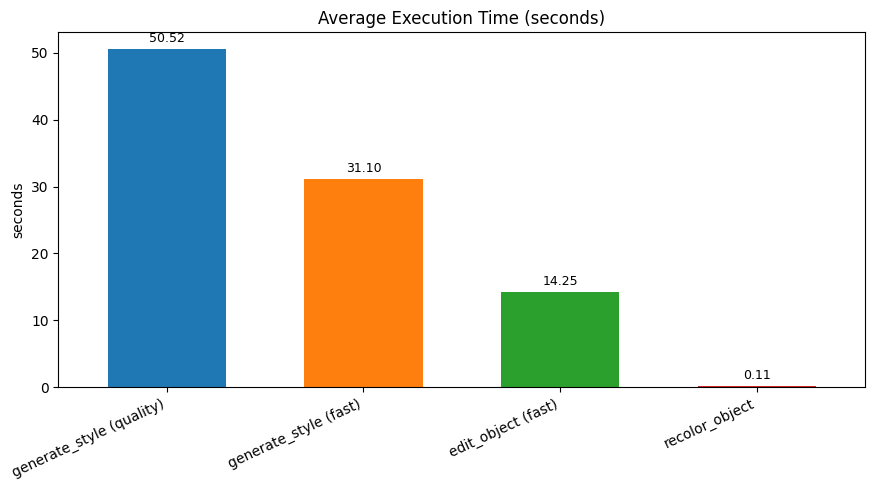

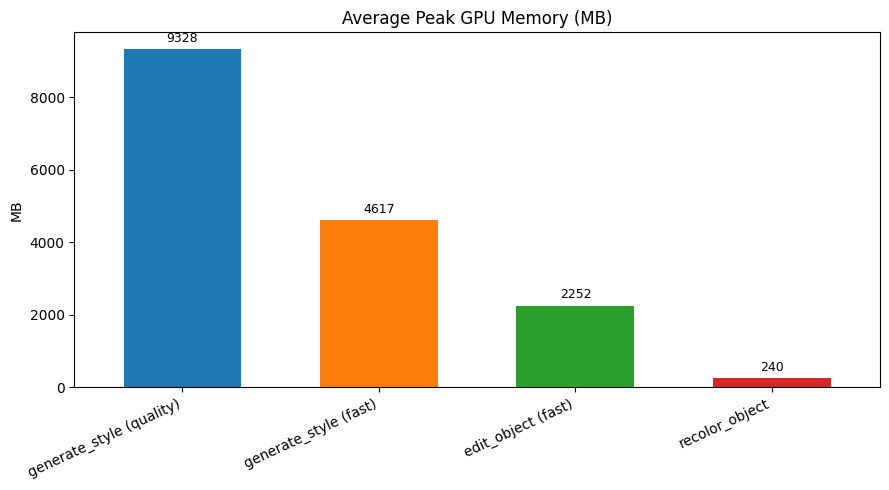

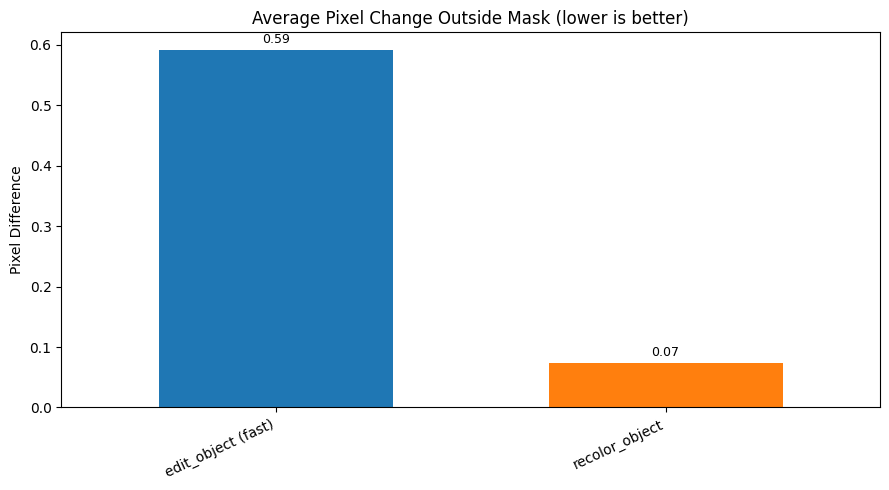

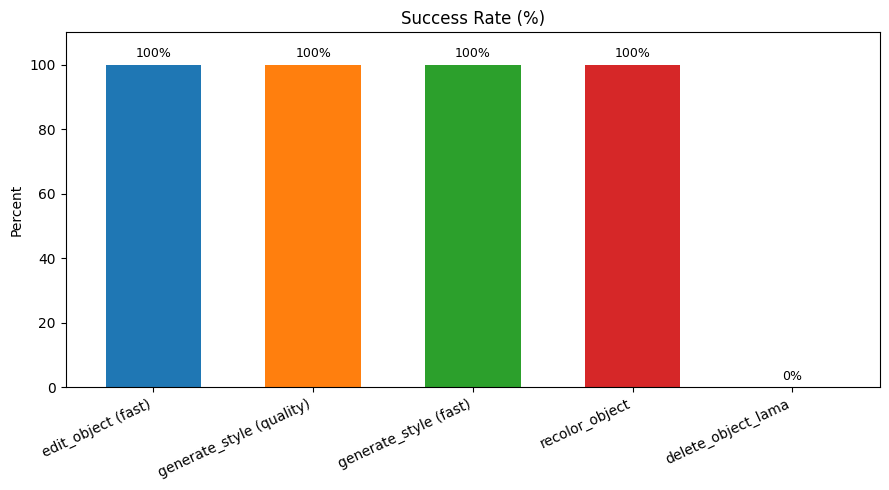


(Quality chart skipped -- human evaluator ratings not yet collected/joined)

4 charts saved to: /content/eval/charts
Excel file saved: /content/eval/evaluation_report.xlsx
Sheets: ['Raw Results', 'Summary', 'Final Report', 'Charts']


In [26]:
try:
    import openpyxl
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openpyxl"])

import matplotlib.pyplot as plt
from openpyxl import Workbook, load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.drawing.image import Image as XLImage

if 'df' not in globals() or df.empty:
    print("No results from the evaluation run -- first run the evaluation execution cell completely.")
else:
    CHARTS_DIR = EVAL_DIR / "charts"
    CHARTS_DIR.mkdir(parents=True, exist_ok=True)

    def add_label(frame):
        frame = frame.copy()
        frame["label"] = frame.apply(
            lambda r: r["operation"] if r["model"] == "-" else f"{r['operation']} ({r['model']})", axis=1)
        return frame

    df_l = add_label(df)
    ok_l = df_l[df_l.success]
    _palette = plt.get_cmap("tab10")

    def bar_chart(data, value_col, title, ylabel, filename, fmt="{:.2f}", ylim=None):
        agg = data.groupby("label")[value_col].mean().sort_values(ascending=False)
        colors = [_palette(i % 10) for i in range(len(agg))]
        fig, ax = plt.subplots(figsize=(9, 5))
        agg.plot(kind="bar", ax=ax, color=colors, width=0.6)
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel("")
        if ylim:
            ax.set_ylim(*ylim)
        for container in ax.containers:
            ax.bar_label(container, fmt=fmt, fontsize=9, padding=3)
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        path = CHARTS_DIR / filename
        plt.savefig(path, dpi=150)
        plt.show()
        return path

    chart_paths = {}
    chart_paths["Execution Time"] = bar_chart(ok_l, "time_sec", "Average Execution Time (seconds)", "seconds", "time_sec.png")
    chart_paths["GPU Memory"] = bar_chart(ok_l, "peak_mem_mb", "Average Peak GPU Memory (MB)", "MB", "peak_mem_mb.png", fmt="{:.0f}")

    diff_data = ok_l.dropna(subset=["pixel_diff_outside_mask"])
    if not diff_data.empty:
        chart_paths["Localized Accuracy"] = bar_chart(diff_data, "pixel_diff_outside_mask",
                                              "Average Pixel Change Outside Mask (lower is better)",
                                              "Pixel Difference", "pixel_diff.png")

    success_pct = df_l.assign(success_pct=df_l["success"] * 100)
    chart_paths["Success Rate"] = bar_chart(success_pct, "success_pct", "Success Rate (%)", "Percent",
                                          "success_rate.png", fmt="{:.0f}%", ylim=(0, 110))

    if 'combined_summary' in globals() and not combined_summary.empty and combined_summary["quality_mean"].notna().any():
        cs_l = add_label(combined_summary.reset_index())
        chart_paths["Human Quality"] = bar_chart(cs_l, "quality_mean", "Average Human Quality Rating (out of 5)",
                                                "Rating", "quality_mean.png", ylim=(0, 5.8))
    else:
        print("\n(Quality chart skipped -- human evaluator ratings not yet collected/joined)")

    print(f"\n{len(chart_paths)} charts saved to: {CHARTS_DIR}")

    xlsx_path = EVAL_DIR / "evaluation_report.xlsx"
    wb = Workbook()
    wb.remove(wb.active)
    header_font = Font(bold=True, color="FFFFFF")
    header_fill = PatternFill("solid", fgColor="4472C4")

    def write_sheet(name, data):
        ws = wb.create_sheet(name)
        for r in dataframe_to_rows(data, index=False, header=True):
            ws.append(r)
        for cell in ws[1]:
            cell.font = header_font
            cell.fill = header_fill
            cell.alignment = Alignment(horizontal="center")
        for col in ws.columns:
            values = [str(c.value) for c in col if c.value is not None]
            width = max((len(v) for v in values), default=10) + 2
            ws.column_dimensions[col[0].column_letter].width = min(40, max(10, width))
        ws.freeze_panes = "A2"
        return ws

    write_sheet("Raw Results", df)
    write_sheet("Summary", summary.reset_index())
    if 'combined_summary' in globals() and not combined_summary.empty:
        write_sheet("Final Report", combined_summary.reset_index())

    ws_charts = wb.create_sheet("Charts")
    row = 1
    for name, chart_path in chart_paths.items():
        ws_charts[f"A{row}"] = name
        ws_charts[f"A{row}"].font = Font(bold=True, size=12)
        img = XLImage(str(chart_path))
        img.anchor = f"A{row + 1}"
        ws_charts.add_image(img)
        row += 28

    wb.save(xlsx_path)
    print(f"Excel file saved: {xlsx_path}")
    print("Sheets:", load_workbook(xlsx_path).sheetnames)
